Core libraries imported.
Project directories ready.
Environment loaded. Model tiers:
  WEAK   -> gpt-4o-mini
  MID    -> gpt-5.4-mini
  STRONG -> gpt-5.4
Conditions: ['C1', 'C2', 'C3', 'C4', 'C5']
Datasets   : ['D1', 'D2', 'D2_fin', 'D3']
Grayscale plotting style configured.
Condition styles: {'C1': '0.15', 'C2': '0.3', 'C3': '0.45', 'C4': '0.6', 'C5': '0.75'}
Live check skipped (set RUN_LIVE_CHECK=True to test credentials).
Setup complete. Config snapshot saved.
Loaded full results: n=32598.
Datasets: ['D1', 'D2', 'D2_fin'] | Models: ['MID', 'STRONG', 'WEAK']


,dataset,model_tier,condition,n,EX,col_recall,col_precision,tbl_recall,ctx_tokens,strength
0,D1,MID,C4,1034,0.7611,0.9212,0.1624,1.0000,371.6925,0
1,D1,MID,C5_L1,1034,0.7631,0.9208,0.1641,1.0000,363.5899,1
2,D1,MID,C5_L2,1034,0.6973,0.8360,0.2898,0.9114,175.2166,2
3,D1,MID,C5_L3,1034,0.4855,0.6303,0.4419,0.9114,105.5890,3
4,D1,STRONG,C4,1034,0.7776,0.9212,0.1624,1.0000,371.6925,0
5,D1,STRONG,C5_L1,1034,0.7776,0.9208,0.1641,1.0000,363.5899,1
6,D1,STRONG,C5_L2,1034,0.7176,0.8360,0.2898,0.9114,175.2166,2
7,D1,STRONG,C5_L3,1034,0.5222,0.6303,0.4419,0.9114,105.5890,3
8,D1,WEAK,C4,1034,0.7437,0.9212,0.1624,1.0000,371.6925,0
9,D1,WEAK,C5_L1,1034,0.7418,0.9208,0.1641,1.0000,363.5899,1


Saved table: 06_rq4_table.csv, 06_rq4_table.tex


C:\Users\miy\AppData\Local\Temp\ipykernel_28428\2572858851.py:108: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  exv = [sub.dropna(subset=["exec_match"])
C:\Users\miy\AppData\Local\Temp\ipykernel_28428\2572858851.py:108: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  exv = [sub.dropna(subset=["exec_match"])
C:\Users\miy\AppData\Local\Temp\ipykernel_28428\2572858851.py:108: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  exv = [sub.dropna(subset=["exec_match"])
C:\Users\miy\AppData\Local\Temp\ipykernel_28428\2572858851.py:108: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  exv = [sub.dropna(subset=["exec_match"])


Saved figure: 06_rq4_strength_curve.png, 06_rq4_strength_curve.pdf


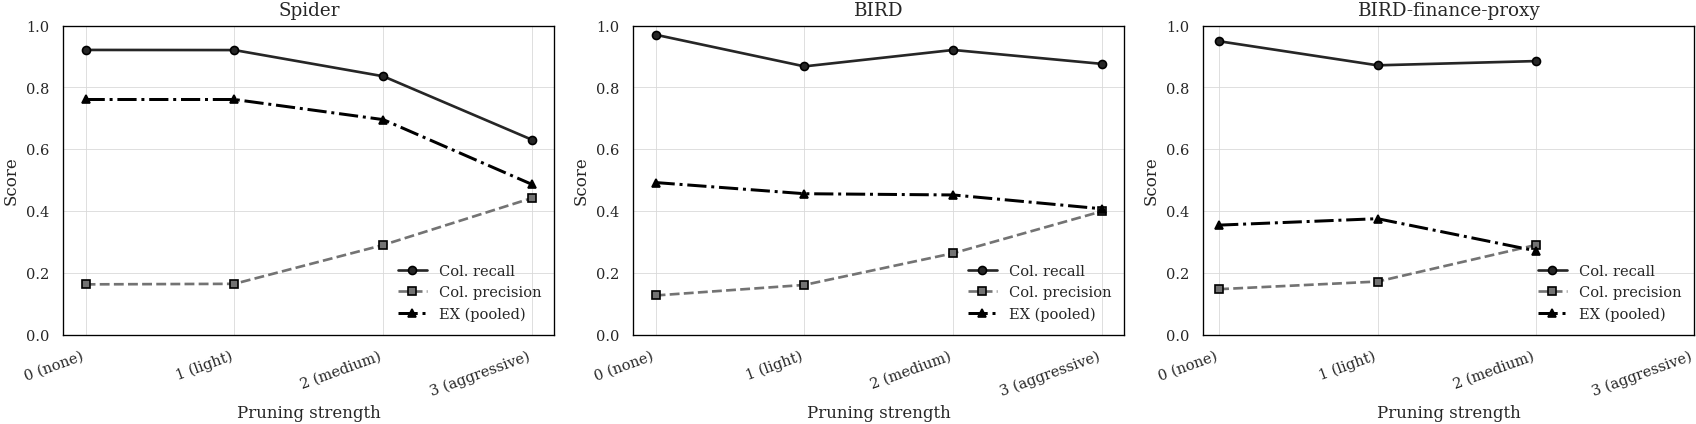

Saved figure: 06_rq4_recall_vs_ex.png, 06_rq4_recall_vs_ex.pdf


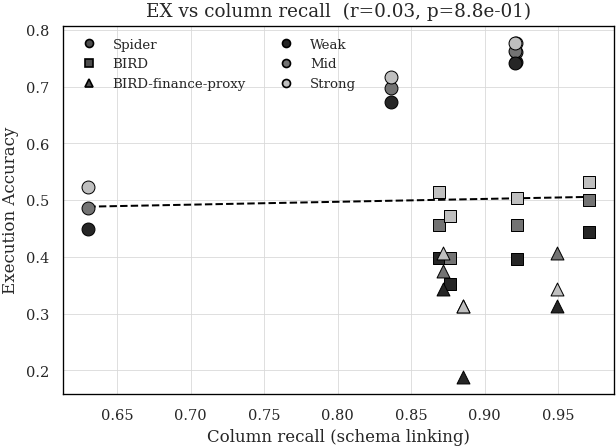

Saved figure: 06_rq4_model_interaction_all.png, 06_rq4_model_interaction_all.pdf


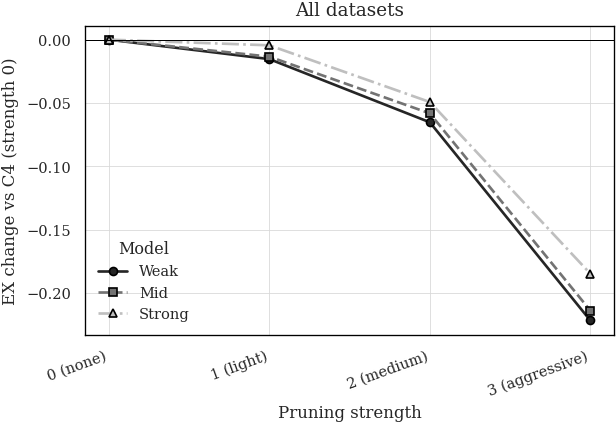

Saved figure: 06_rq4_model_interaction_D1.png, 06_rq4_model_interaction_D1.pdf


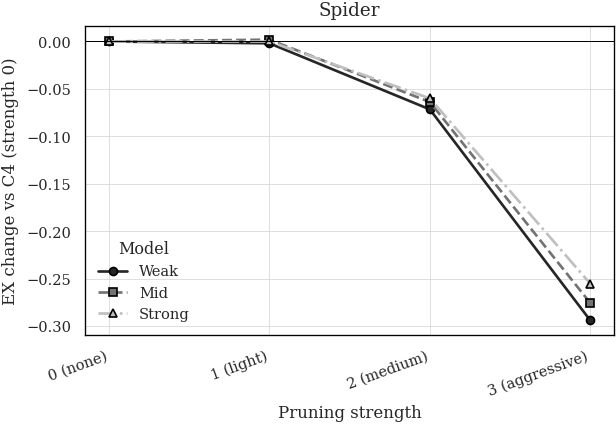

Saved figure: 06_rq4_model_interaction_D2.png, 06_rq4_model_interaction_D2.pdf


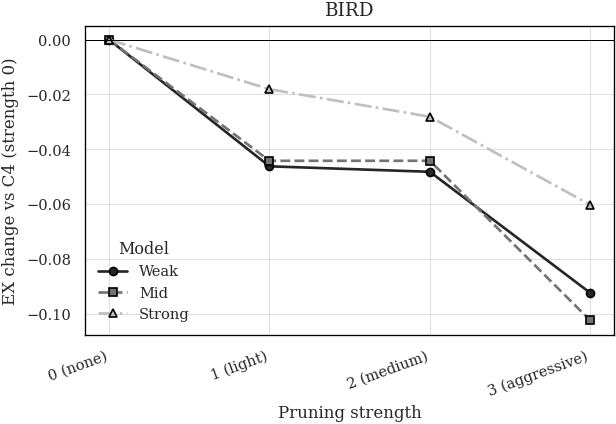

Saved figure: 06_rq4_model_interaction_D2_fin.png, 06_rq4_model_interaction_D2_fin.pdf


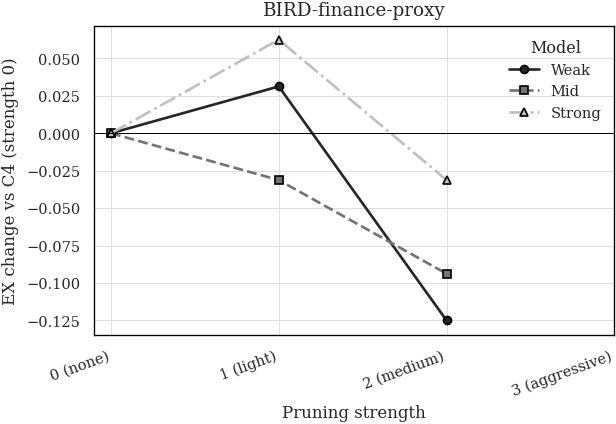

[ALL] interaction (strength x model) on EX:


,term,coef,se,t,p
0,intercept,0.6730,0.0093,71.993,0.0000
1,strength,-0.0722,0.0050,-14.392,0.0000
2,model_rank,0.0249,0.0072,3.433,0.0006
3,strength x model,0.0058,0.0039,1.490,0.1363


[D1] interaction (strength x model) on EX:


,term,coef,se,t,p
0,intercept,0.7953,0.0109,73.261,0.0000
1,strength,-0.0953,0.0058,-16.423,0.0000
2,model_rank,0.0140,0.0084,1.668,0.0954
3,strength x model,0.0063,0.0045,1.399,0.1619


[D2] interaction (strength x model) on EX:


,term,coef,se,t,p
0,intercept,0.4429,0.0169,26.144,0.0000
1,strength,-0.0303,0.0091,-3.348,0.0008
2,model_rank,0.0476,0.0131,3.627,0.0003
3,strength x model,0.0044,0.0070,0.630,0.5288


[D2_fin] interaction (strength x model) on EX:


,term,coef,se,t,p
0,intercept,0.3620,0.0696,5.203,0.0000
1,strength,-0.0651,0.0539,-1.208,0.2280
2,model_rank,0.0130,0.0539,0.242,0.8092
3,strength x model,0.0234,0.0417,0.561,0.5749


In [1]:
# ============================================================================
# 06_rq4_pruning_slm.ipynb
# ----------------------------------------------------------------------------
# Beyond Full-Schema Prompting: A Graph-based Semantic Layer for Text-to-SQL
#
# RQ4 (reframed): How does deterministic pruning STRENGTH interact with model
#      capability? The data show pruning trades recall for precision/token-savings;
#      past a point recall loss dominates and EX falls. We test whether that fall
#      is steeper for weaker models, and we expose the recall-precision-EX
#      trade-off curve across pruning levels (C4 -> C5_L1 -> L2 -> L3).
#
# This notebook also produces the KEY evidence for the reframed thesis
# ("the bottleneck is schema linking"): EX tracks retrieval recall, not model size.
#
# Consumes : results/tables/generation_results.csv
# Produces : 06_rq4_strength_curve.{png,pdf}      recall/precision/EX vs strength
#            06_rq4_recall_vs_ex.{png,pdf}         EX tracks recall (bottleneck)
#            06_rq4_model_interaction.{png,pdf}    dEX by model across strengths
#            06_rq4_table.{csv,tex}
#
# Anonymity: no filesystem paths are printed.
# ============================================================================


# %% [markdown]
# ## Cell 1 - Load configuration + results

# %%
%run 00_setup_and_config.ipynb


# %%
from scipy import stats

def load_results():
    full = TABLES_DIR / "generation_results.csv"
    smoke = TABLES_DIR / "generation_results_smoke.csv"
    if full.exists():
        df = pd.read_csv(full); print(f"Loaded full results: n={len(df)}.")
    elif smoke.exists():
        df = pd.read_csv(smoke); print(f"[warning] using SMOKE data (n={len(df)}).")
    else:
        raise FileNotFoundError("Run notebook 02 first.")
    return df

res = load_results()


# %% [markdown]
# ## Cell 2 - Pruning-strength ordering
# We treat C4 as strength 0 (no pruning) and C5_L1/L2/L3 as strengths 1/2/3, so
# every metric can be plotted against an ordinal "pruning strength" axis.

# %%
STRENGTH_ORDER = ["C4", "C5_L1", "C5_L2", "C5_L3"]
STRENGTH_INDEX = {c: i for i, c in enumerate(STRENGTH_ORDER)}
STRENGTH_LABEL = {"C4": "0 (none)", "C5_L1": "1 (light)",
                  "C5_L2": "2 (medium)", "C5_L3": "3 (aggressive)"}

rq4 = res[res["condition"].isin(STRENGTH_ORDER)].copy()
rq4["strength"] = rq4["condition"].map(STRENGTH_INDEX)
# EX-scoreable only for EX means
rq4_ex = rq4.dropna(subset=["exec_match"]).copy()
print("Datasets:", sorted(rq4["dataset"].unique()),
      "| Models:", sorted(rq4["model_tier"].unique()))


# %% [markdown]
# ## Cell 3 - Strength table: EX / recall / precision / tokens by dataset x model

# %%
rq4_table = (rq4.groupby(["dataset", "model_tier", "condition"])
               .agg(n=("qid", "count"),
                    EX=("exec_match", "mean"),
                    col_recall=("col_recall_strict", "mean"),
                    col_precision=("col_precision_strict", "mean"),
                    tbl_recall=("table_recall", "mean"),
                    ctx_tokens=("context_tokens_est", "mean"))
               .reset_index())
rq4_table["strength"] = rq4_table["condition"].map(STRENGTH_INDEX)
rq4_table = rq4_table.sort_values(["dataset", "model_tier", "strength"]).round(4)
display(rq4_table)
save_table(rq4_table, "06_rq4_table")


# %% [markdown]
# ## Cell 4 - Figure: recall / precision / EX vs pruning strength
# One panel per dataset (pooled over models for EX; recall/precision are model-
# independent so shown once). Shows the core trade-off: as strength rises,
# precision & token-savings rise but recall falls, and EX peaks early then drops.

# %%
def plot_strength_curve(df, datasets):
    datasets = [d for d in datasets if d in df["dataset"].unique()]
    if not datasets:
        print("No data."); return
    fig, axes = plt.subplots(1, len(datasets),
                             figsize=(4.8 * len(datasets), 3.8), squeeze=False)
    for ax, ds in zip(axes[0], datasets):
        sub = df[df["dataset"] == ds]
        xs = list(range(len(STRENGTH_ORDER)))
        # recall & precision (model-independent -> average over rows)
        rec = [sub[sub["condition"] == c]["col_recall_strict"].mean()
               for c in STRENGTH_ORDER]
        prec = [sub[sub["condition"] == c]["col_precision_strict"].mean()
                for c in STRENGTH_ORDER]
        # EX pooled over models (scoreable rows only)
        exv = [sub.dropna(subset=["exec_match"])
               [sub["condition"] == c]["exec_match"].mean()
               for c in STRENGTH_ORDER]
        ax.plot(xs, rec, color="0.15", linestyle="-", marker="o",
                markeredgecolor="black", linewidth=1.6, label="Col. recall")
        ax.plot(xs, prec, color="0.45", linestyle="--", marker="s",
                markeredgecolor="black", linewidth=1.6, label="Col. precision")
        ax.plot(xs, exv, color="0.0", linestyle="-.", marker="^",
                markeredgecolor="black", linewidth=1.8, label="EX (pooled)")
        ax.set_xticks(xs)
        ax.set_xticklabels([STRENGTH_LABEL[c] for c in STRENGTH_ORDER],
                           rotation=20, ha="right")
        ax.set_ylim(0, 1.0)
        ax.set_xlabel("Pruning strength")
        ax.set_ylabel("Score")
        ax.set_title(DATASETS.get(ds, ds))
        ax.legend()
    save_figure(fig, "06_rq4_strength_curve")
    plt.show()

plot_strength_curve(rq4, sorted(rq4["dataset"].unique()))


# %% [markdown]
# ## Cell 5 - Figure: EX tracks retrieval recall (the bottleneck evidence)
# Scatter of per-cell (col_recall, EX) across all conditions/datasets/models.
# A strong positive relationship supports "the bottleneck is schema linking":
# once recall drops, EX drops regardless of model or pruning label.

# %%
def plot_recall_vs_ex(df):
    d = df.dropna(subset=["exec_match"])
    cell = (d.groupby(["dataset", "condition", "model_tier"])
              .agg(recall=("col_recall_strict", "mean"),
                   EX=("exec_match", "mean")).reset_index())
    fig, ax = plt.subplots(figsize=(5.4, 4.0))
    # marker encodes dataset, gray encodes model tier
    ds_markers = {ds: MARKERS[i % len(MARKERS)]
                  for i, ds in enumerate(sorted(cell["dataset"].unique()))}
    tier_gray = {t: gray_palette(len(MODEL_TIER_ORDER))[i]
                 for i, t in enumerate(MODEL_TIER_ORDER)}
    for _, r in cell.iterrows():
        ax.scatter(r["recall"], r["EX"], s=60,
                   marker=ds_markers.get(r["dataset"], "o"),
                   color=tier_gray.get(r["model_tier"], "0.3"),
                   edgecolor="black", linewidth=0.6, zorder=3)
    # correlation
    if len(cell) >= 3:
        rr, pp = stats.pearsonr(cell["recall"], cell["EX"])
        z = np.polyfit(cell["recall"], cell["EX"], 1)
        xs = np.linspace(cell["recall"].min(), cell["recall"].max(), 50)
        ax.plot(xs, np.polyval(z, xs), color="black", linewidth=1.2, linestyle="--")
        ax.set_title(f"EX vs column recall  (r={rr:.2f}, p={pp:.1e})")
    ax.set_xlabel("Column recall (schema linking)")
    ax.set_ylabel("Execution Accuracy")
    # legends
    from matplotlib.lines import Line2D
    ds_handles = [Line2D([0], [0], marker=m, color="0.3", linestyle="",
                         markeredgecolor="black", label=DATASETS.get(ds, ds))
                  for ds, m in ds_markers.items()]
    tier_handles = [Line2D([0], [0], marker="o", color=g, linestyle="",
                           markeredgecolor="black", label=MODEL_TIER_LABELS[t])
                    for t, g in tier_gray.items()]
    ax.legend(handles=ds_handles + tier_handles, fontsize=8, ncol=2)
    save_figure(fig, "06_rq4_recall_vs_ex")
    plt.show()
    return cell

recall_ex_cells = plot_recall_vs_ex(rq4)


# %% [markdown]
# ## Cell 6 - Figure: model x strength interaction (delta-EX from C4)
# For each model tier, plot EX drop relative to C4 (strength 0) as strength rises.
# Steeper decline for weaker models supports the reframed RQ4 (SLMs are more
# fragile to recall loss). Pooled across datasets, and also per dataset.

# %%
def plot_model_interaction(df, dataset=None):
    d = df.dropna(subset=["exec_match"])
    if dataset:
        d = d[d["dataset"] == dataset]
    base = (d[d["condition"] == "C4"]
            .groupby("model_tier")["exec_match"].mean())
    fig, ax = plt.subplots(figsize=(5.4, 3.8))
    tiers = [t for t in MODEL_TIER_ORDER if t in d["model_tier"].unique()]
    for i, t in enumerate(tiers):
        ex = [d[(d["condition"] == c) & (d["model_tier"] == t)]["exec_match"].mean()
              for c in STRENGTH_ORDER]
        dex = [e - base.get(t, np.nan) for e in ex]
        ax.plot(range(len(STRENGTH_ORDER)), dex,
                color=gray_palette(len(tiers))[i],
                linestyle=LINE_STYLES[i % len(LINE_STYLES)],
                marker=MARKERS[i % len(MARKERS)], markeredgecolor="black",
                linewidth=1.6, label=MODEL_TIER_LABELS.get(t, t))
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_xticks(range(len(STRENGTH_ORDER)))
    ax.set_xticklabels([STRENGTH_LABEL[c] for c in STRENGTH_ORDER],
                       rotation=20, ha="right")
    ax.set_xlabel("Pruning strength")
    ax.set_ylabel("EX change vs C4 (strength 0)")
    ax.set_title("All datasets" if not dataset else DATASETS.get(dataset, dataset))
    ax.legend(title="Model")
    tag = "all" if not dataset else dataset
    save_figure(fig, f"06_rq4_model_interaction_{tag}")
    plt.show()

plot_model_interaction(rq4)                       # pooled
for ds in sorted(rq4["dataset"].unique()):
    plot_model_interaction(rq4, dataset=ds)       # per dataset


# %% [markdown]
# ## Cell 7 - Two-way interaction test (strength x model on EX)
# OLS with strength (ordinal), model tier (ordinal), and their interaction.
# A significant negative interaction = stronger pruning hurts weaker models more.

# %%
def interaction_test(df, dataset=None):
    d = df.dropna(subset=["exec_match"]).copy()
    if dataset:
        d = d[d["dataset"] == dataset]
    tier_rank = {"WEAK": 0, "MID": 1, "STRONG": 2}
    d["model_rank"] = d["model_tier"].map(tier_rank)
    d["inter"] = d["strength"] * d["model_rank"]
    X = np.column_stack([np.ones(len(d)), d["strength"], d["model_rank"], d["inter"]])
    y = d["exec_match"].values
    # OLS via least squares
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    dof = len(y) - X.shape[1]
    sigma2 = (resid @ resid) / dof
    cov = sigma2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(cov))
    tvals = beta / se
    pvals = 2 * (1 - stats.t.cdf(np.abs(tvals), dof))
    names = ["intercept", "strength", "model_rank", "strength x model"]
    out = pd.DataFrame({"term": names, "coef": beta.round(4),
                        "se": se.round(4), "t": tvals.round(3),
                        "p": pvals.round(4)})
    print(f"[{dataset or 'ALL'}] interaction (strength x model) on EX:")
    display(out)
    return out

_ = interaction_test(rq4)
for ds in sorted(rq4["dataset"].unique()):
    _ = interaction_test(rq4, dataset=ds)